# Train CNN with with Colab (GPU)

## Mounting to google colab, creating folders, loading from google drive...

In [1]:
from pathlib import Path
import sys
import numpy as np


try:
    from google.colab import drive
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    drive.mount("/content/drive") # mount the drive
    DATA_PATH = Path("/content/drive/MyDrive") # the root of the drive
    DATA_ROOT = DATA_PATH / "cbc_pe_data" # the root of the data
else:
    PROJECT_ROOT = Path.cwd().parent
    sys.path.insert(0, str(PROJECT_ROOT))
    DATA_ROOT = PROJECT_ROOT / "data"


DATA_RAW = DATA_ROOT / "raw" # the root of the raw data
DATA_PROCESSED = DATA_ROOT / "processed" # the root of the processed data
MODELS_DIR = DATA_ROOT / "models" # the root of the models
RESULTS_DIR = DATA_ROOT / "results" # the root of the results
CHECKPOINTS_DIR = MODELS_DIR / "checkpoints" # the root of the checkpoints

for path in [DATA_RAW, DATA_PROCESSED, MODELS_DIR, RESULTS_DIR, CHECKPOINTS_DIR]:
    path.mkdir(parents=True, exist_ok=True)

print("DATA_ROOT:", DATA_ROOT)
print("DATA_RAW:", DATA_RAW)
print("MODELS_DIR:", MODELS_DIR)
print("RESULTS_DIR:", RESULTS_DIR)
print("CHECKPOINTS_DIR:", CHECKPOINTS_DIR)




DATA_ROOT: /home/victor/gw/cbc_pe/data
DATA_RAW: /home/victor/gw/cbc_pe/data/raw
MODELS_DIR: /home/victor/gw/cbc_pe/data/models
RESULTS_DIR: /home/victor/gw/cbc_pe/data/results
CHECKPOINTS_DIR: /home/victor/gw/cbc_pe/data/models/checkpoints


Clone repository if it doesn't exist

In [2]:
from pathlib import Path
import sys
import os

if IN_COLAB:
    REPO_ROOT = Path("/content/Gravitational-Waves-Lab")
    PROJECT_ROOT = REPO_ROOT / "cbc_pe"

    if not REPO_ROOT.exists():
        !git clone https://github.com/victorsh13/Gravitational-Waves-Lab.git /content/Gravitational-Waves-Lab

    print("REPO_ROOT exists:", REPO_ROOT.exists())
    print("PROJECT_ROOT exists:", PROJECT_ROOT.exists())

We make a pull from the repository to get the latest version of the code.

In [3]:
if IN_COLAB:
    %cd /content/Gravitational-Waves-Lab
    !git pull
    !git status

Configure the impots

In [4]:
os.chdir(PROJECT_ROOT)

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print("cwd:", Path.cwd())
print("sys.path[:3]:", sys.path[:3])

cwd: /home/victor/gw/cbc_pe
sys.path[:3]: ['/home/victor/gw/cbc_pe', '/usr/lib/python312.zip', '/usr/lib/python3.12']


## Load the data

In [5]:
from src.io import load_dataset_npz

dataset_path = DATA_RAW / "cbc_dataset_5000.npz"

print(dataset_path.exists())

batch = load_dataset_npz(dataset_path)

X = batch.X
y = batch.y
network_snrs = batch.network_snrs   
metadata = batch.metadata

print("X:", batch.X.shape)
print("y:", batch.y.shape)
print("network_snrs:", len(batch.network_snrs))
print("metadata:", batch.metadata)


True
X: (5000, 3, 16384)
y: (5000, 3)
network_snrs: 5000
metadata: {'detector_names': ['H1', 'L1', 'V1']}


Split the data into:
- ``train``       : training the model
- ``val``         : early stopping / chosing the best model
- ``calibration`` : calibration of the conformal intervals
- ``test``        : final evaluation, independent of the model/training/calibration

Some reasonable splits: 70/10/10/10 

In [6]:
import numpy as np


n_samples = X.shape[0]
rng = np.random.default_rng(seed=13)

indices = rng.permutation(n_samples)
split_fractions = [0.7, 0.1, 0.1, 0.1] # Train, Val, Cal, Test

if sum(split_fractions) != 1:
    raise ValueError("Split fractions must sum to 1")

n_train = int(split_fractions[0] * n_samples)
n_val = int(split_fractions[1] * n_samples)
n_cal = int(split_fractions[2] * n_samples)
n_test = n_samples - n_train - n_val - n_cal

print(f"Samples: \n - Train: {n_train}\n - Val: {n_val}\n - Cal: {n_cal}\n - Test: {n_test}")

idx_train = indices[:n_train]
idx_val = indices[n_train:n_train+n_val]
idx_cal = indices[n_train+n_val:n_train+n_val+n_cal]
idx_test = indices[n_train+n_val+n_cal:]

# Save splits to compare models properly
np.savez(
    DATA_PROCESSED / "splits_cbc_dataset_5000.npz",
    idx_train=idx_train,
    idx_val=idx_val,
    idx_cal=idx_cal,
    idx_test=idx_test,
)



X_train, y_train = X[idx_train], y[idx_train]
X_val, y_val = X[idx_val], y[idx_val]
X_cal, y_cal = X[idx_cal], y[idx_cal]
X_test, y_test = X[idx_test], y[idx_test]





Samples: 
 - Train: 3500
 - Val: 500
 - Cal: 500
 - Test: 500


Standarize the labels using the mean and standard deviation of the training set and save it in DATA_PROCESSED.
This will be needed to revert the normalization and interpret the predictions as physical quantities.

In [7]:
y_mean = y_train.mean(axis=0)
y_std = y_train.std(axis=0) + 1e-8

y_train_std = (y_train - y_mean) / y_std
y_val_std = (y_val - y_mean) / y_std
y_cal_std = (y_cal - y_mean) / y_std
y_test_std = (y_test - y_mean) / y_std


# Save it in file:
file_name_std = "standardization_params_5000.npz"

np.savez(
    DATA_PROCESSED / file_name_std,
    mean=y_mean,
    std=y_std,
)

Create PyTorch datasets

In [8]:
from src.models.dataset import ArrayRegressionDataset

train_dataset = ArrayRegressionDataset(X_train, y_train_std)
val_dataset = ArrayRegressionDataset(X_val, y_val_std)
cal_dataset = ArrayRegressionDataset(X_cal, y_cal_std)
test_dataset = ArrayRegressionDataset(X_test, y_test_std)

And loaders

In [9]:
from torch.utils.data import DataLoader

batch_size = 32

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
)

val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False,
)

cal_loader = DataLoader(
    cal_dataset,
    batch_size=batch_size,
    shuffle=False,
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False,
)

## Train the CNN and save the model

In [10]:
import torch

print(torch.cuda.is_available())
print(torch.cuda.device_count())

True
1


In [11]:
%cd /content/Gravitational-Waves-Lab/cbc_pe

[Errno 2] No such file or directory: '/content/Gravitational-Waves-Lab/cbc_pe'
/home/victor/gw/cbc_pe/notebooks


In [12]:
import copy
import torch
import torch.nn as nn

from src.models.train import train_one_epoch, validate_one_epoch
from src.models.network import SimpleCNN

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

dropout_conv = 0.05
dropout_dense = 0.1
embedding_dim = 64

model = SimpleCNN(
    n_detectors=3,
    n_outputs=3,
    embedding_dim=embedding_dim,
    dropout_conv=dropout_conv,
    dropout_dense=dropout_dense,
).to(device)

learning_rate = 3e-4
weight_decay = 1e-4
max_epochs = 100
patience = 15

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=learning_rate,
    weight_decay=weight_decay,
)

loss_fn = nn.MSELoss()

loss_train = []
loss_val = []

best_val_loss = float("inf")
best_checkpoint = None
epochs_without_improvement = 0

for epoch in range(max_epochs):
    train_loss = train_one_epoch(
        model=model,
        loader=train_loader,
        loss_fn=loss_fn,
        optimizer=optimizer,
        device=device,
    )

    val_loss = validate_one_epoch(
        model=model,
        loader=val_loader,
        loss_fn=loss_fn,
        device=device,
    )

    loss_train.append(train_loss)
    loss_val.append(val_loss)

    improved = val_loss < best_val_loss

    if improved:
        best_val_loss = val_loss
        epochs_without_improvement = 0

        best_checkpoint = {
            "epoch": epoch + 1,
            "model_state_dict": copy.deepcopy(model.state_dict()),
            "optimizer_state_dict": copy.deepcopy(optimizer.state_dict()),
            "train_loss": train_loss,
            "val_loss": val_loss,
            "y_mean": torch.as_tensor(y_mean, dtype=torch.float32),
            "y_std": torch.as_tensor(y_std, dtype=torch.float32),
            "model_config": {
                "n_detectors": 3,
                "n_outputs": 3,
                "embedding_dim": embedding_dim,
                "dropout_conv": dropout_conv,
                "dropout_dense": dropout_dense,
            },
        }
    else:
        epochs_without_improvement += 1

    print(
        f"Epoch {epoch+1:03d} | "
        f"train_loss = {train_loss:.6f} | "
        f"val_loss = {val_loss:.6f} | "
        f"best_val = {best_val_loss:.6f}"
    )

    if epochs_without_improvement >= patience:
        print(f"Early stopping at epoch {epoch+1}")
        break

Using device: cuda
Epoch 001 | train_loss = 1.003120 | val_loss = 0.964640 | best_val = 0.964640
Epoch 002 | train_loss = 1.000943 | val_loss = 0.967320 | best_val = 0.964640
Epoch 003 | train_loss = 1.001733 | val_loss = 0.964895 | best_val = 0.964640
Epoch 004 | train_loss = 0.999432 | val_loss = 0.965683 | best_val = 0.964640
Epoch 005 | train_loss = 0.978050 | val_loss = 0.882241 | best_val = 0.882241
Epoch 006 | train_loss = 0.836033 | val_loss = 0.771344 | best_val = 0.771344
Epoch 007 | train_loss = 0.786563 | val_loss = 0.759241 | best_val = 0.759241
Epoch 008 | train_loss = 0.770444 | val_loss = 0.745389 | best_val = 0.745389
Epoch 009 | train_loss = 0.748997 | val_loss = 0.734119 | best_val = 0.734119
Epoch 010 | train_loss = 0.725734 | val_loss = 0.698132 | best_val = 0.698132
Epoch 011 | train_loss = 0.702786 | val_loss = 0.684823 | best_val = 0.684823
Epoch 012 | train_loss = 0.698869 | val_loss = 0.685935 | best_val = 0.684823
Epoch 013 | train_loss = 0.679989 | val_loss 

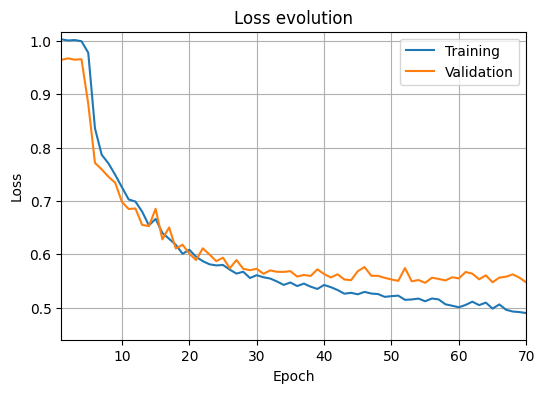

In [13]:
import matplotlib.pyplot as plt
import numpy as np


fig, ax = plt.subplots(1, 1, figsize=(6, 4))

last_epoch = len(loss_train)
plt.plot(np.arange(1, last_epoch+1), loss_train, label="Training")
plt.plot(np.arange(1, last_epoch+1), loss_val, label="Validation")
ax.set_xlim(1, last_epoch)
ax.set_ylim(min(loss_train)-0.05, max(loss_val)+0.05)
ax.set_xlabel("Epoch")
ax.set_ylabel("Loss")
ax.set_title("Loss evolution")
ax.legend()
ax.grid()


After the training, the model is saved to the output directory.

In [14]:
checkpoint_file_name = "simple_cnn_5000_30.pt"

torch.save(
    best_checkpoint,
    CHECKPOINTS_DIR / checkpoint_file_name,
)

And to load the training data:

In [15]:
from src.models.network import SimpleCNN
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
checkpoint_file_name = "simple_cnn_5000_30.pt"

checkpoint = torch.load(
    CHECKPOINTS_DIR / checkpoint_file_name,
    map_location=device,
)

model = SimpleCNN(
    n_detectors=checkpoint["model_config"]["n_detectors"],
    n_outputs=checkpoint["model_config"]["n_outputs"],
    embedding_dim=checkpoint["model_config"]["embedding_dim"],
    dropout_conv=checkpoint["model_config"]["dropout_conv"],
    dropout_dense=checkpoint["model_config"]["dropout_dense"],
    #n_filters=checkpoint["model_config"]["n_filters"],
)

model.load_state_dict(checkpoint["model_state_dict"])
model = model.to(device)
model.eval()

SimpleCNN(
  (block1): ConvBlock(
    (conv): Conv1d(3, 16, kernel_size=(16,), stride=(2,), padding=(8,))
    (group_norm): GroupNorm(8, 16, eps=1e-05, affine=True)
    (activation): LeakyReLU(negative_slope=0.01)
    (dropout): Dropout(p=0.05, inplace=False)
  )
  (block2): ConvBlock(
    (conv): Conv1d(16, 32, kernel_size=(16,), stride=(2,), padding=(8,))
    (group_norm): GroupNorm(8, 32, eps=1e-05, affine=True)
    (activation): LeakyReLU(negative_slope=0.01)
    (dropout): Dropout(p=0.05, inplace=False)
  )
  (block3): ConvBlock(
    (conv): Conv1d(32, 64, kernel_size=(16,), stride=(2,), padding=(8,))
    (group_norm): GroupNorm(8, 64, eps=1e-05, affine=True)
    (activation): LeakyReLU(negative_slope=0.01)
    (dropout): Dropout(p=0.05, inplace=False)
  )
  (block4): ConvBlock(
    (conv): Conv1d(64, 128, kernel_size=(16,), stride=(2,), padding=(8,))
    (group_norm): GroupNorm(8, 128, eps=1e-05, affine=True)
    (activation): LeakyReLU(negative_slope=0.01)
    (dropout): Dropout

### Comprobar el error en test

In [16]:
from src.models.train import validate_one_epoch

test_loss = validate_one_epoch(model=model, loader=test_loader, loss_fn=loss_fn, device=device)
print("Test loss:", test_loss)

Test loss: 0.5098236453533173


### Extraer predicciones y embeddings (After training)

In [17]:
print("Best epoch:", checkpoint["epoch"])

Best epoch: 55


In [18]:
@torch.no_grad()
def extract_predictions_and_embeddings(model, loader, device):
    model.eval()

    all_pred = []
    all_emb = []
    all_y = []

    for X_batch, y_batch in loader:
        X_batch = X_batch.to(device)

        pred, emb = model(X_batch, return_embedding=True)

        all_pred.append(pred.cpu().numpy())
        all_emb.append(emb.cpu().numpy())
        all_y.append(y_batch.numpy())

    pred = np.concatenate(all_pred, axis=0)
    emb = np.concatenate(all_emb, axis=0)
    y = np.concatenate(all_y, axis=0)

    return pred, emb, y

Get the predictions, embeddings and labels for the calibration and test sets.

In [19]:
pred_cal, emb_cal, y_cal = extract_predictions_and_embeddings(
    model,
    cal_loader,
    device,
)

pred_test, emb_test, y_test = extract_predictions_and_embeddings(
    model,
    test_loader,
    device,
)

And the we save all the results (predictions, embeddings, labels) to use later in Mondrian.

In [20]:
np.savez_compressed(
    RESULTS_DIR / "cnn_predictions_embeddings_5000_50.npz", # Number samples + number epochs
    pred_cal=pred_cal,
    emb_cal=emb_cal,
    y_cal=y_cal,
    pred_test=pred_test,
    emb_test=emb_test,
    y_test=y_test,
    y_mean=y_mean,
    y_std=y_std,
)

## Sanity checks

In [21]:
baseline_train_mse = np.mean(y_train_std ** 2)
baseline_val_mse = np.mean(y_val_std ** 2)
baseline_cal_mse = np.mean(y_cal_std ** 2)
baseline_test_mse = np.mean(y_test_std ** 2)

print("Baseline train:", baseline_train_mse)
print("Baseline val:", baseline_val_mse)
print("Baseline cal:", baseline_cal_mse)
print("Baseline test:", baseline_test_mse)

Baseline train: 0.9999998
Baseline val: 0.96740365
Baseline cal: 1.0012403
Baseline test: 0.97378445


Study validation error (MSE and MAE) per label

In [23]:
from src.models.train import evaluate_per_label_mse
mse_val, mae_val = evaluate_per_label_mse(model, val_loader, device)
mse_test, mae_test = evaluate_per_label_mse(model, test_loader, device)

#for name, mse, mae in zip(["chirp_mass", "total_mass", "chi_eff"], mse_val, mae_val):
for i, name in enumerate(["chirp_mass", "total_mass", "chi_eff"]):
    print("\nValidation:")
    print(f"{name}: MSE={mse_val[i]:.4f}, MAE={mae_val[i]:.4f}")
    print("\nTest:")
    print(f"{name}: MSE={mse_test[i]:.4f}, MAE={mae_test[i]:.4f}")



Validation:
chirp_mass: MSE=0.4530, MAE=0.5169

Test:
chirp_mass: MSE=0.3882, MAE=0.4908

Validation:
total_mass: MSE=0.3721, MAE=0.4930

Test:
total_mass: MSE=0.3240, MAE=0.4545

Validation:
chi_eff: MSE=0.8143, MAE=0.7432

Test:
chi_eff: MSE=0.8173, MAE=0.7453


Plot the predictions vs the true values of the validation set

In [24]:
from src.models.train import predict_on_loader

pred_val_std, y_val_std = predict_on_loader(
    model,
    val_loader,
    device,
)


y_mean = checkpoint["y_mean"].cpu().numpy()
y_std = checkpoint["y_std"].cpu().numpy()

pred_val = pred_val_std * y_std + y_mean
y_val_true = y_val_std * y_std + y_mean

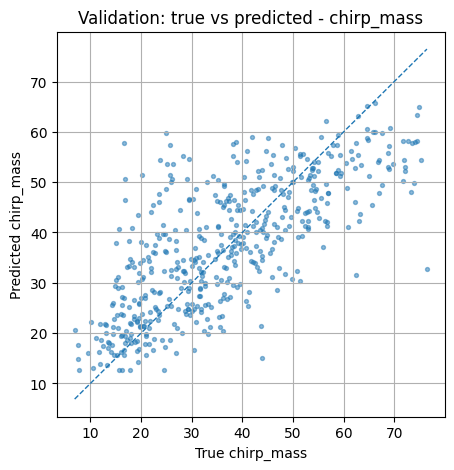

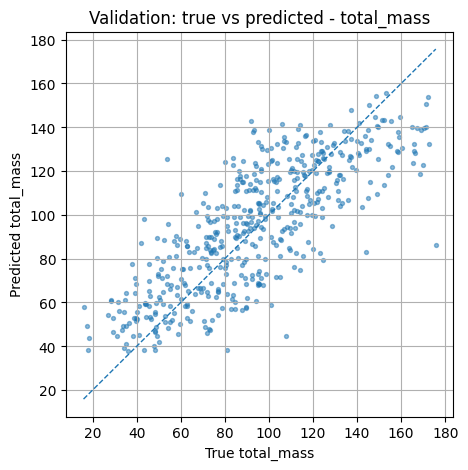

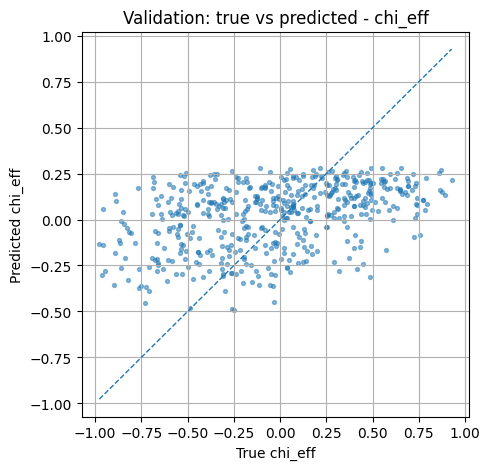

In [25]:
#Plot pred vs true for the 3 labels (chirp_mass, total_mass, chi_eff)
import matplotlib.pyplot as plt
import numpy as np

label_names = ["chirp_mass", "total_mass", "chi_eff"]

for j, name in enumerate(label_names):
    plt.figure(figsize=(5, 5))

    plt.scatter(
        y_val_true[:, j],
        pred_val[:, j],
        s=8,
        alpha=0.5,
    )

    min_val = min(y_val_true[:, j].min(), pred_val[:, j].min())
    max_val = max(y_val_true[:, j].max(), pred_val[:, j].max())

    plt.plot(
        [min_val, max_val],
        [min_val, max_val],
        linestyle="--",
        linewidth=1,
    )

    plt.xlabel(f"True {name}")
    plt.ylabel(f"Predicted {name}")
    plt.title(f"Validation: true vs predicted - {name}")
    plt.grid(True)
    plt.show()




Also plot the residuals

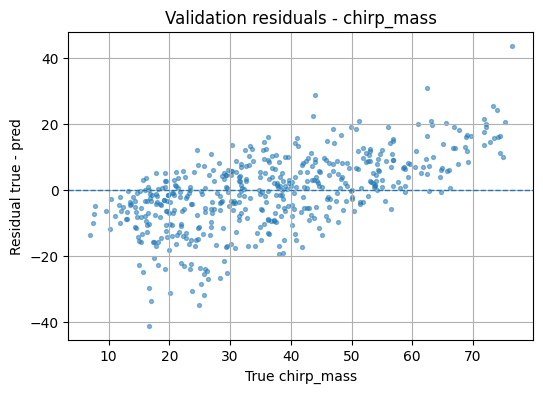

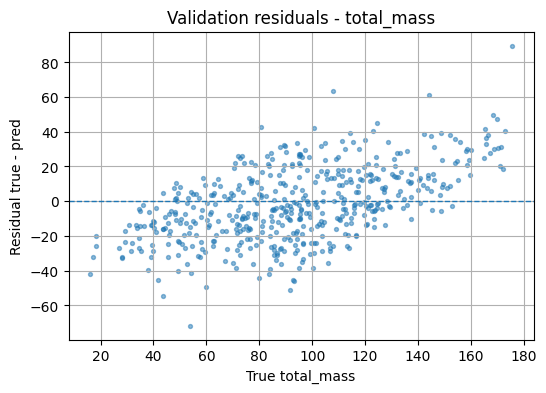

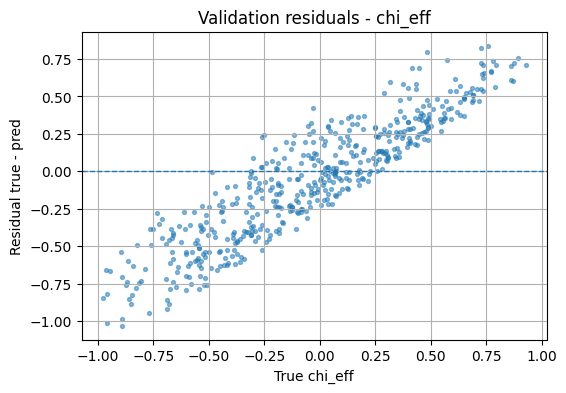

In [26]:
for j, name in enumerate(label_names):
    residual = y_val_true[:, j] - pred_val[:, j]

    plt.figure(figsize=(6, 4))

    plt.scatter(
        y_val_true[:, j],
        residual,
        s=8,
        alpha=0.5,
    )

    plt.axhline(0.0, linestyle="--", linewidth=1)

    plt.xlabel(f"True {name}")
    plt.ylabel(f"Residual true - pred")
    plt.title(f"Validation residuals - {name}")
    plt.grid(True)
    plt.show()

Check the scale of the data

In [27]:
print("X_train mean:", X_train.mean())
print("X_train std:", X_train.std())
print("X_train min:", X_train.min())
print("X_train max:", X_train.max())

for d in range(3):
    print(
        f"Detector {d}: "
        f"mean={X_train[:, d, :].mean():.4e}, "
        f"std={X_train[:, d, :].std():.4e}, "
        f"min={X_train[:, d, :].min():.4e}, "
        f"max={X_train[:, d, :].max():.4e}"
    )

X_train mean: -2.1522977e-12
X_train std: 0.7905694
X_train min: -9.196567
X_train max: 8.24648
Detector 0: mean=9.7498e-13, std=7.9057e-01, min=-7.0544e+00, max=7.1226e+00
Detector 1: mean=3.8812e-12, std=7.9057e-01, min=-7.2588e+00, max=7.5995e+00
Detector 2: mean=-7.5712e-12, std=7.9057e-01, min=-9.1966e+00, max=8.2465e+00


In [28]:
N_small = 512

X_small = X_train[:N_small]
y_small = y_train_std[:N_small]

small_dataset = ArrayRegressionDataset(X_small, y_small)

small_loader = DataLoader(
    small_dataset,
    batch_size=128,
    shuffle=True,
)

model = SimpleCNN(
    n_detectors=3,
    n_outputs=3,
    embedding_dim=64,
).to(device)

loss_fn = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=3e-4, weight_decay=1e-4)

for epoch in range(200):
    train_loss = train_one_epoch(
        model=model,
        loader=small_loader,
        loss_fn=loss_fn,
        optimizer=optimizer,
        device=device,
    )

    if (epoch + 1) % 20 == 0:
        print(f"Epoch {epoch+1:03d} | train_loss = {train_loss:.6f}")

Epoch 020 | train_loss = 0.986396
Epoch 040 | train_loss = 0.982364
Epoch 060 | train_loss = 0.959790
Epoch 080 | train_loss = 0.795018
Epoch 100 | train_loss = 0.624380
Epoch 120 | train_loss = 0.548084
Epoch 140 | train_loss = 0.498589
Epoch 160 | train_loss = 0.490754
Epoch 180 | train_loss = 0.441467
Epoch 200 | train_loss = 0.435635


### Testing the GPU

In [ ]:
import torch

print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
    props = torch.cuda.get_device_properties(0)
    print("Total VRAM [GB]:", props.total_memory / 1024**3)

In [ ]:

print("Allocated [GB]:", torch.cuda.memory_allocated() / 1024**3)
print("Reserved [GB]:", torch.cuda.memory_reserved() / 1024**3)
print("Peak allocated [GB]:", torch.cuda.max_memory_allocated() / 1024**3)
print("Peak reserved [GB]:", torch.cuda.max_memory_reserved() / 1024**3)

In [ ]:
def test_batch_size(model, batch_size, n_detectors=3, signal_length=16384, device="cuda"):
    try:
        torch.cuda.empty_cache()
        torch.cuda.reset_peak_memory_stats()

        model.train()

        X = torch.randn(batch_size, n_detectors, signal_length, device=device)
        y = torch.randn(batch_size, 3, device=device)

        optimizer = torch.optim.AdamW(model.parameters(), lr=3e-4, weight_decay=1e-4)
        loss_fn = torch.nn.MSELoss()

        optimizer.zero_grad()
        pred = model(X)
        loss = loss_fn(pred, y)
        loss.backward()
        optimizer.step()

        peak = torch.cuda.max_memory_allocated() / 1024**3
        print(f"batch_size={batch_size} OK | peak VRAM = {peak:.2f} GB")

        del X, y, pred, loss
        torch.cuda.empty_cache()

        return True

    except RuntimeError as e:
        if "out of memory" in str(e).lower():
            print(f"batch_size={batch_size} OOM")
            torch.cuda.empty_cache()
            return False
        else:
            raise e

In [ ]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'

for bs in [32, 64, 96, 128, 192]:
    ok = test_batch_size(model, bs, device=device)
    if not ok:
        break